Based on https://github.com/XENON1T/CEvNS/blob/master/notebooks/B8_neutrino_spectrum.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json as js
from tqdm import tqdm

import pickle

from scipy.interpolate import interp1d

In [2]:
params = {
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
    'font.family' : 'serif',
    'font.size' : 15,
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    'xtick.major.size' : 8,
    'ytick.major.size' : 8,
    'xtick.major.width' : 1.5,
    'ytick.major.width' : 1.5,
    'axes.linewidth' : 1.5,
    'axes.labelsize' : 17
}

plt.rcParams.update(params)
# plt.rc('text', usetex=True)

In [3]:
""" IN SI UNIT """
""" Reduced Planck Constant in J·s """
HBAR = 1.054571800E-34
""" Speed of Light in m/s """
C = 2.99792458E8
""" Avogaro's Number in 1/mol """
A_V = 6.022140857E23
""" Charge of Electron in C """
CH_E = 1.6021766208E-19

""" keV in J """
KEV = 1e3 * CH_E
""" GeV in J """
GEV = 1e9 * CH_E

In [4]:
Xe124 = {
    'Type'		: 'Xe124',
    'MassNum'	: 124,
    'AtomicNum'	: 54,
    'Mass'		: 123.905893,
    'Spin'		: 0,
    'Fraction'	: 9.52E-4
}

Xe126 = {
    'Type'		: 'Xe126',
    'MassNum'	: 126,
    'AtomicNum'	: 54,
    'Mass'		: 125.904274,
    'Spin'		: 0,
    'Fraction'	: 8.90E-4
}

Xe128 = {
    'Type'		: 'Xe128',
    'MassNum'	: 128,
    'AtomicNum'	: 54,
    'Mass'		: 127.9035313,
    'Spin'		: 0,
    'Fraction'	: 0.019102
}

Xe129 = {
    'Type'		: 'Xe129',
    'MassNum'	: 129,
    'AtomicNum'	: 54,
    'Mass'		: 128.9047794,
    'Spin'		: 0.5,
    'Fraction'	: 0.264006
}

Xe130 = {
    'Type'		: 'Xe130',
    'MassNum'	: 130,
    'AtomicNum'	: 54,
    'Mass'		: 129.9035080,
    'Spin'		: 0,
    'Fraction'	: 0.040710
}

Xe131 = {
    'Type'		: 'Xe131',
    'MassNum'	: 131,
    'AtomicNum'	: 54,
    'Mass'		: 130.9050824,
    'Spin'		: 1.5,
    'Fraction'	: 0.212324
}

Xe132 = {
    'Type'		: 'Xe132',
    'MassNum'	: 132,
    'AtomicNum'	: 54,
    'Mass'		: 131.9041535,
    'Spin'		: 0,
    'Fraction'	: 0.269086
}

Xe134 = {
    'Type'		: 'Xe134',
    'MassNum'	: 134,
    'AtomicNum'	: 54,
    'Mass'		: 133.9053945,
    'Spin'		: 0,
    'Fraction'	: 0.104357
}

Xe136 = {
    'Type'		: 'Xe136',
    'MassNum'	: 136,
    'AtomicNum'	: 54,
    'Mass'		: 135.907219,
    'Spin'		: 0,
    'Fraction'	: 0.088573
}

ATOM_TABLE = {
    'Xe124'	: Xe124,
    'Xe126'	: Xe126,
    'Xe128'	: Xe128,
    'Xe129'	: Xe129,
    'Xe130'	: Xe130,
    'Xe131'	: Xe131,
    'Xe132'	: Xe132,
    'Xe134'	: Xe134,
    'Xe136'	: Xe136
}

In [5]:
GeV = 1.0
MeV = GeV / 1e3
keV = GeV / 1e6
eV = GeV / 1e9

# GeV ^ -1
m = 1.0 / (HBAR * C / GEV) / GeV
cm = m / 1e2
km = m * 1e3
mm = m / 1e3
um = m / 1e6
nm = m / 1e9
pm = m / 1e12
fm = m / 1e15

# GeV
kg = 1.0 * C**2 / GEV * GeV
ton = kg * 1e3
g = kg * 1e-3

# GeV ^ -1
sec = 1.0 * C * m
dy = 24.0 * 3600.0 * sec
yr = 365.0 * dy

# Fermi's const
Gf = 1.1663787e-5 / GeV**2

# Neutron mass
mn = 0.9314940954 * GeV

# Mixing angle
sin2the = 0.2223

# Standard model CEvNS spectrum

In [6]:
from scipy.special import spherical_jn
from scipy.integrate import quad

class TARGET(object):
    def __init__(self, atom, pure = False):
        super(TARGET, self).__init__()
        self.target = atom
        self.spin = atom["Spin"]
        self.abund = 1 if pure else atom["Fraction"]
        self.A = atom["MassNum"]
        self.Z = atom["AtomicNum"]
        self.N = self.A - self.Z
        self.mass = atom["Mass"] * mn
        self.Qw = self.N - (1 - 4.0 * sin2the) * self.Z
    
    def TransMoment(self, Er):
        return np.sqrt(2 * self.mass * Er)
    
    def MinNeutrinoEnergy(self, Er):
        return (Er + np.sqrt(Er**2 + 2 * self.mass * Er)) / 2.0
    
    def MaxRecoilEnergy(self, Ev):
        return 2 * Ev**2 / (self.mass + 2 * Ev)
    
    def FormFactor(self, q):
        if q == 0:
            return 1.0
        a = 0.52 * fm
        c = (1.23 * self.A**(1.0/3.0) - 0.6) * fm
        s = 0.9 * fm
        rn = np.sqrt(c**2 + 7.0 / 3.0 * np.pi**2 * a**2 - 5 * s**2)
        qrn = q * rn
        return (3 * spherical_jn(1, qrn) / qrn)**2 * np.exp(- (q * s)**2)

    #cross-section as given in equation 2 page 9 of CEvNS paper
    def dXsecdErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            return 0
        q = self.TransMoment(Er)
        return Gf**2 / 4.0 / np.pi * self.Qw**2 * self.mass * (1 - self.mass * Er / 2 / Ev**2) * self.FormFactor(q)
    
    def Integrator(self, func, xmin, xmax):
        result, foo = quad(func, xmin, xmax)
        return result
    
    #modified by Riya
    #Assuming mono-energetic neutrinos
    #it is returning events/(ton*keV*Fluence) where fluence is flux integrated over time and so units of cm^(-2)
    def dRatedErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            #print(".")
            return 0
        # f(_ev)=F*delta(_ev), so no-integration
        return self.dXsecdErecoil(Er, Ev) * self.abund / self.mass * (cm**(-2))

In [7]:
NaturalXe = [TARGET(ATOM_TABLE["Xe124"], pure = False),
          TARGET(ATOM_TABLE["Xe126"], pure = False),
          TARGET(ATOM_TABLE["Xe128"], pure = False),
          TARGET(ATOM_TABLE["Xe129"], pure = False),
          TARGET(ATOM_TABLE["Xe130"], pure = False),
          TARGET(ATOM_TABLE["Xe131"], pure = False),
          TARGET(ATOM_TABLE["Xe132"], pure = False),
          TARGET(ATOM_TABLE["Xe134"], pure = False),
          TARGET(ATOM_TABLE["Xe136"], pure = False)]

Number of target atoms:

In [41]:
N_T = sum([xe.abund/xe.mass for xe in NaturalXe]) * ton
N_T

4.588020143230578e+27

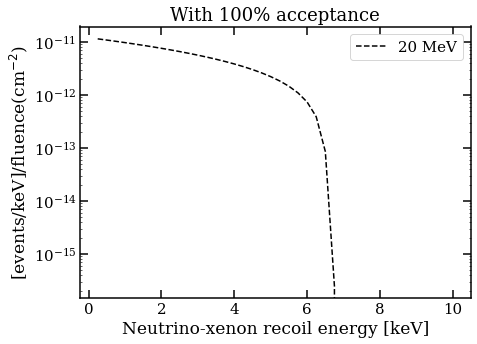

In [8]:
er = np.linspace(0.25, 10, 40)*keV
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.semilogy(er / keV, tot_rate * ton / (keV**(-1)), 'k--', label="20 MeV")

ax.legend()
ax.set_title("With 100% acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

#  Acceptance

s2only_efficiency.csv is created using https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb

where 'Energy' = d['es'] & 'Efficiency' = d['efficiency_nounc']

This efficiency includes reduction in fiducial target mass from 2.004 tonne.

In [9]:
acc_data = pd.read_csv('s2only_efficiency.csv')
accept = acc_data['Efficiency']*0.7 #because 30% of data is used for training
energy_S2only = acc_data['Energy'] * keV
accept_S2only = interp1d(energy_S2only, accept, bounds_error=False, fill_value=0, kind='linear')

In [10]:
acc_data = pd.read_csv('NR_acceptance_NSI_UL_200811.csv').drop(columns='Unnamed: 0')
accept = acc_data['acceptance']
energy_2fold = acc_data['energy'] * keV
accept_2fold = interp1d(energy_2fold, accept, bounds_error=False, fill_value=0, kind='linear')

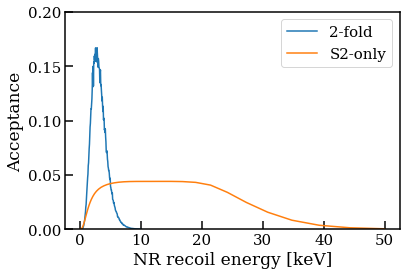

In [11]:
plt.plot(energy_2fold / keV, accept_2fold(energy_2fold), label="2-fold")
plt.plot(energy_S2only / keV, accept_S2only(energy_S2only), label="S2-only")
#plt.xlim(0, 10)
plt.ylim(0, 0.2)
plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.legend()
plt.show()

Acceptance for 3-fold is available at https://github.com/XENON1T/SR1Results/tree/master/Calibration/TemplateFiles/180420/run_combined_source_combined/acceptances

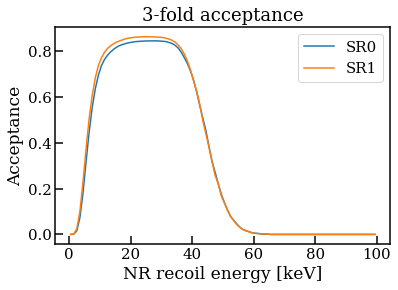

In [16]:
acceptanceFileNames = [
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr0', # SR0 WIMPs
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr1'  # SR1 WIMPs
]
percentiles = [pickle.load(open(af + '.pkl', 'rb')) for af in acceptanceFileNames]

energyEdges = percentiles[0]['energy_edges']* keV
energy_3fold = (energyEdges[1:] + energyEdges[:-1]) / 2.

accept = percentiles[0]['energy']['totalcombacc'].T[1]
accept_3fold_SR0 = interp1d(energy_3fold, accept, bounds_error=False, fill_value=0, kind='linear')

accept = percentiles[1]['energy']['totalcombacc'].T[1]
accept_3fold_SR1 = interp1d(energy_3fold, accept, bounds_error=False, fill_value=0, kind='linear')

plt.plot(energy_3fold / keV, accept_3fold_SR0(energy_3fold), label="SR0")
plt.plot(energy_3fold / keV, accept_3fold_SR1(energy_3fold), label="SR1")

plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.title("3-fold acceptance")
plt.legend()
plt.show()

# Events in 1 tonne detector at fixed Energy

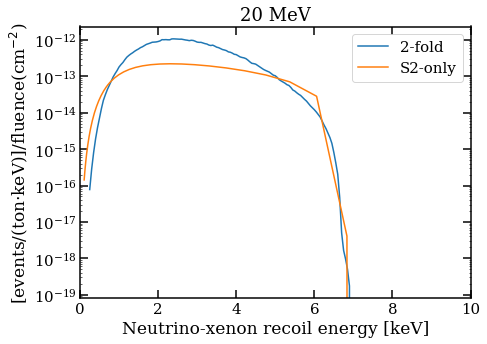

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


er = []
for i in range(0,np.shape(energy_2fold)[0]-1):
    er.append((energy_2fold[i]+energy_2fold[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="2-fold")


er = []
for i in range(0,np.shape(energy_S2only)[0]-1):
    er.append((energy_S2only[i]+energy_S2only[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="S2-only")



ax.legend()
ax.set_title(r"20 MeV")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

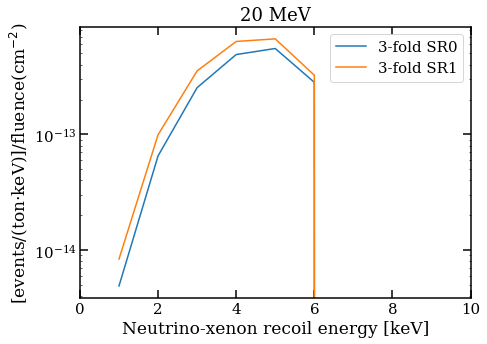

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

er = []
for i in range(0,np.shape(energy_3fold)[0]-1):
    er.append((energy_3fold[i]+energy_3fold[i+1])/2)
er=np.array(er)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR0")

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR1")

ax.legend()
ax.set_title(r"20 MeV")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

# Events in detector at fixed Energy with desired fiducial mass

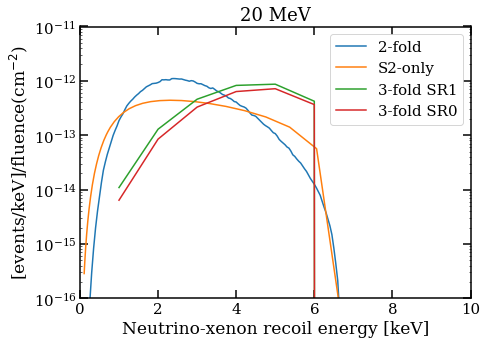

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


er = []
for i in range(0,np.shape(energy_2fold)[0]-1):
    er.append((energy_2fold[i]+energy_2fold[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
ax.semilogy(er / keV, tot_rate * 1.04 * ton/ keV**(-1), label="2-fold")


er = []
for i in range(0,np.shape(energy_S2only)[0]-1):
    er.append((energy_S2only[i]+energy_S2only[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
ax.semilogy(er / keV, tot_rate * 2.004 * ton/ keV**(-1) , label="S2-only")

er = []
for i in range(0,np.shape(energy_3fold)[0]-1):
    er.append((energy_3fold[i]+energy_3fold[i+1])/2)
er=np.array(er)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR1")
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR0")


ax.legend()
ax.set_title(r"20 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

Checking if integration (area under curve) gives reasonable values

In [20]:
total_rate = 0
for i in range(0,np.shape(energy_S2only)[0]-1):
    er = (energy_S2only[i]+energy_S2only[i+1])/2
    delta_energy = energy_S2only[i+1] - energy_S2only[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_S2only(er)
    total_rate = total_rate + rate * delta_energy * 2.004 * ton
total_rate

1.60943711289097e-12

In [21]:
total_rate = 0
for i in range(0,np.shape(energy_2fold)[0]-1):
    er = (energy_2fold[i]+energy_2fold[i+1])/2
    delta_energy = energy_2fold[i+1] - energy_2fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_2fold(er)
    total_rate = total_rate + rate * delta_energy * 1.04 * ton
total_rate

2.591968631737068e-12

In [22]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

2.1397461040474527e-12

In [23]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

2.715130706614805e-12

# Events in detector for neutrino energies

In [24]:
np.linspace(5, 100, 96)

array([  5.,   6.,   7.,   8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,
        16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,
        27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,
        38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,
        49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,
        60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,
        71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,
        82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,
        93.,  94.,  95.,  96.,  97.,  98.,  99., 100.])

In [25]:
Neutrino_Energy = np.linspace(5, 100, 96)*MeV

def calc_rate_Ev(energy, accept, fm):
    total_rate_Ev = []
    for Ev in Neutrino_Energy:
        total_rate = 0
        for i in range(0,np.shape(energy)[0]-1):
            er = (energy[i]+energy[i+1])/2
            delta_energy = energy[i+1] - energy[i]
            rate = sum([xe.dRatedErecoil(er, Ev) for xe in NaturalXe]) * accept(er)
            total_rate = total_rate + rate * delta_energy * fm * ton
        total_rate_Ev.append(total_rate)
    return(np.array(total_rate_Ev))

In [26]:
fm_3fold = 1.3
fm_2fold = 1.04 
fm_S2only = 2.004 #used in https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb to calculate exposure

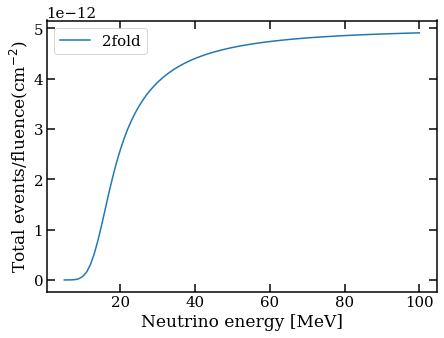

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_2fold, accept_2fold, fm_2fold), label="2fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

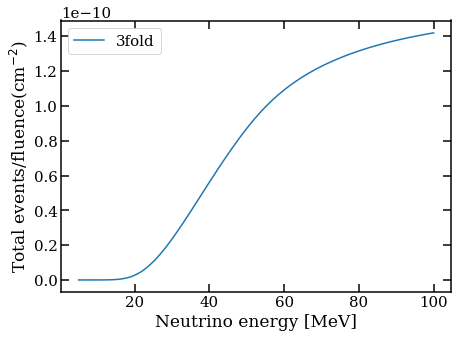

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold), label="3fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

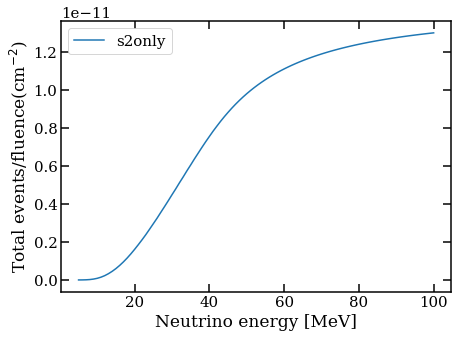

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_S2only, accept_S2only, fm_S2only), label="s2only")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

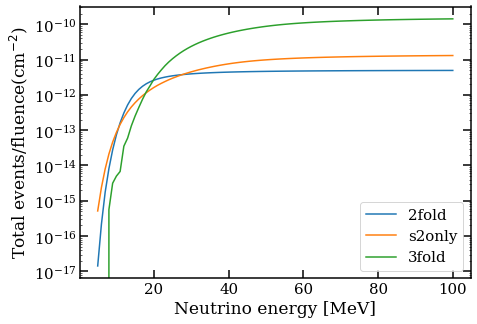

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_2fold, accept_2fold, fm_2fold), label="2fold")
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_S2only, accept_S2only, fm_S2only), label="s2only")
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold), label="3fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
plt.yscale("log")

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

# Set constraints

In [31]:
upper_lim_fluence_2_fold = 2.3/calc_rate_Ev(energy_2fold, accept_2fold, fm_2fold)
upper_lim_fluence_3_fold = 2.3/calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold)
upper_lim_fluence_S2only = 2.3/calc_rate_Ev(energy_S2only, accept_S2only, fm_S2only)

<ipython-input-31-eb86d3e7f140>:2: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold = 2.3/calc_rate_Ev(energy_3fold, accept_3fold_SR1, fm_3fold)


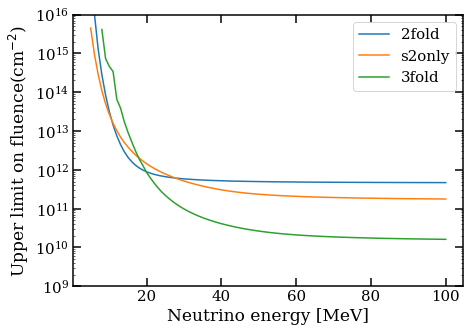

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_2_fold, label="2fold")
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_S2only, label="s2only")
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_3_fold, label="3fold")

ax.legend()
#ax.set_title(r"(Total events/flux ")
ax.set_ylim([1e9, 1e16])
plt.yscale("log")
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

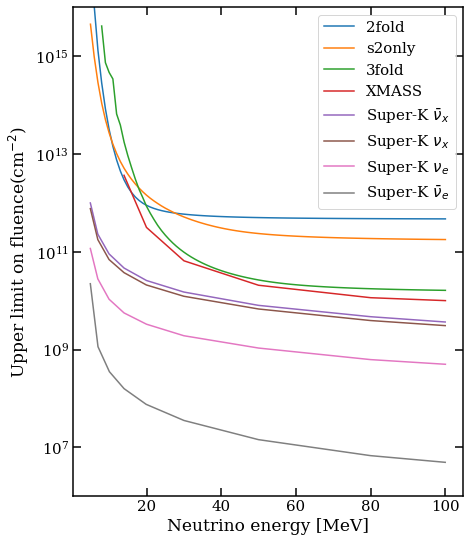

In [33]:
Anti_neutrinio_x = pd.read_csv('Anti_neutrino_x.csv')
neutrinio_x = pd.read_csv('neutrino_x.csv')
Anti_neutrinio_e = pd.read_csv('anti_neutrino_e.csv')
neutrinio_e = pd.read_csv('neutrino_e.csv')
XMASS_neutrinio = pd.read_csv('XMASS_neutrino.csv')

fig, ax = plt.subplots(1, 1, figsize=(7,9))
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_2_fold, label="2fold")
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_S2only, label="s2only")
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_3_fold, label="3fold")
plt.plot(XMASS_neutrinio['Energy'], XMASS_neutrinio['fluence'], label="XMASS")
plt.plot(Anti_neutrinio_x['Energy'], Anti_neutrinio_x['fluence'], label=r"Super-K $\bar{\nu}_x$")
plt.plot(neutrinio_x['Energy'], neutrinio_x['fluence'], label=r"Super-K ${\nu}_x$")
plt.plot(neutrinio_e['Energy'], neutrinio_e['fluence'], label=r"Super-K ${\nu}_e$")
plt.plot(Anti_neutrinio_e['Energy'], Anti_neutrinio_e['fluence'], label=r"Super-K $\bar{\nu}_e$")

ax.legend()
#ax.set_title(r"(Total events/flux ")
ax.set_ylim([1e6, 1e16])
plt.yscale("log")
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [34]:
XMASS_neutrinio

,Energy,fluence
0,13.980926,3.638692e+12
1,19.995385,3.131111e+11
2,30.024784,6.506397e+10
3,49.983209,2.059746e+10
4,80.008655,1.146240e+10
5,100.009207,9.989050e+09


For 30 Gev/c^2 dark matter limits on dark matter cross-section (in cm^2):

3-fold -> 4.5 * 10^-46

S2-only -> 4.5 * 10^-45

i.e. an order magnitude worse. Matches with our limits.

# Sanity Checks - 80 MeV Neutrinos

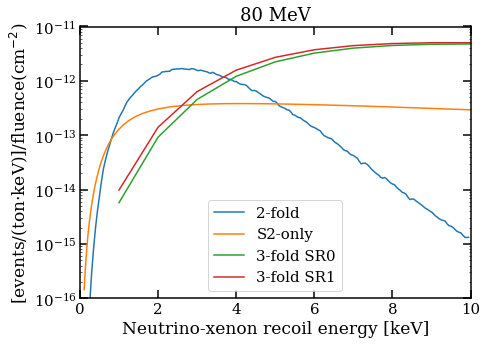

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


er = []
for i in range(0,np.shape(energy_2fold)[0]-1):
    er.append((energy_2fold[i]+energy_2fold[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="2-fold")


er = []
for i in range(0,np.shape(energy_S2only)[0]-1):
    er.append((energy_S2only[i]+energy_S2only[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="S2-only")

er = []
for i in range(0,np.shape(energy_3fold)[0]-1):
    er.append((energy_3fold[i]+energy_3fold[i+1])/2)
er=np.array(er)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR0")

tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR1")

ax.legend()
ax.set_title(r"80 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [36]:
total_rate = 0
for i in range(0,np.shape(energy_S2only)[0]-1):
    er = (energy_S2only[i]+energy_S2only[i+1])/2
    delta_energy = energy_S2only[i+1] - energy_S2only[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_S2only(er)
    total_rate = total_rate + rate * delta_energy * 2.004 * ton
total_rate

1.2390942667886128e-11

In [37]:
total_rate = 0
for i in range(0,np.shape(energy_2fold)[0]-1):
    er = (energy_2fold[i]+energy_2fold[i+1])/2
    delta_energy = energy_2fold[i+1] - energy_2fold[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_2fold(er)
    total_rate = total_rate + rate * delta_energy * 1.04 * ton
total_rate

4.85843435610784e-12

In [38]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR1(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

1.3156777279577983e-10

# Axion limits

In [42]:
N_T

4.588020143230578e+27

In [43]:
efficiency_ER = 0.89 #figure 2 of https://arxiv.org/pdf/2006.09721.pdf

In [44]:
Cross_section = 10**(-28) #cm^2 #XENONnT limit for 10 keV ALPs https://arxiv.org/pdf/2207.11330.pdf

In [45]:
N_T * efficiency_ER * Cross_section

0.4083337927475214

In [49]:
UL_fluence = 2.3/(N_T * efficiency_ER * Cross_section)
UL_fluence

5.632646723956356

In [47]:
Mpc = 3.0857*10**22 #m
distance_merger = 40 * Mpc #m #for GW170817

In [50]:
UL_fluence * (4*3.14*distance_merger**2)

1.0777785512244096e+50